<a href="https://colab.research.google.com/github/IrisCheon/nlp-practice/blob/main/Clickbait_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clickbait Classification Practice
This notebook explores clickbait headline classification using TF-IDF vectorisation and Logistic Regression.

The notebook includes:
- exploratory data analysis (EDA)
- TF-IDF text vectorisation
- Logistic Regression baseline modelling
- evaluation using precision, recall, F1-score, and confusion matrix
- threshold analysis
- comparison of unigram, bigram, and trigram features
- inspection of feature importance and borderline examples

In [186]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amananandrai/clickbait-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'clickbait-dataset' dataset.
Path to dataset files: /kaggle/input/clickbait-dataset


In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

#■ 데이터 확인

In [188]:
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, 'clickbait_data.csv'))
df.head()

['clickbait_data.csv']


,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1
3,"This Vine Of New York On ""Celebrity Big Brothe...",1
4,A Couple Did A Stunning Photo Shoot With Their...,1


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   headline   32000 non-null  object
 1   clickbait  32000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 500.1+ KB


In [190]:
df["clickbait"].value_counts()

,count
clickbait,
0,16001
1,15999


In [191]:
df["headline_length"] = df["headline"].str.len()
df.groupby("clickbait")["headline_length"].describe()
# 길이와 관련해서는 큰 차이 없음

,count,mean,std,min,25%,50%,75%,max
clickbait,,,,,,,,
0,16001.0,51.853322,14.357056,11.0,42.0,49.0,60.0,135.0
1,15999.0,55.741046,14.923931,6.0,46.0,56.0,65.0,125.0


#■ ML
- Logistic Regression

In [192]:
from sklearn.model_selection import train_test_split

In [193]:
X = df["headline"]
y = df["clickbait"]

In [194]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [195]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [196]:
model = Pipeline(
    [("tfidf", TfidfVectorizer(
        max_features= 50000,
        ngram_range=(1,2),
        stop_words = 'english')),
     ("clf", LogisticRegression(
         max_iter = 1000))]
)

In [197]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [198]:
y_pred = model.predict(X_test)

In [199]:
from sklearn.metrics import classification_report, confusion_matrix

In [200]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3127
           1       0.97      0.93      0.95      3273

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



In [201]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[3031,   96],
       [ 221, 3052]])

In [202]:
import seaborn as sns

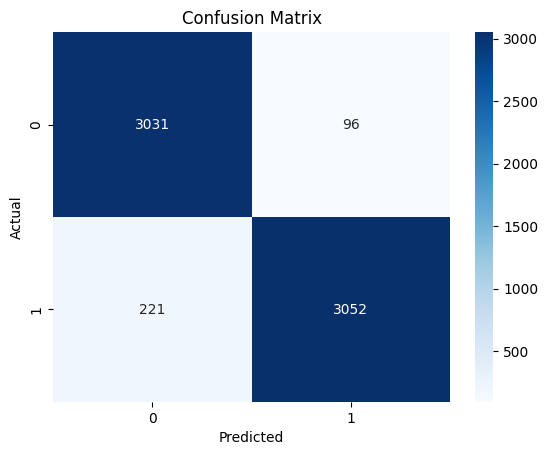

In [203]:
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# FN이 FP의 2배 이상 >

#■ Threshold Analysis

In [204]:
y_proba = model.predict_proba(X_test)[:,1]

In [205]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [206]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
thresholds_results = []

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    thresholds_results.append({
        "threshold" : t,
        "precision" : precision_score(y_test, y_pred_t),
        "recall" : recall_score(y_test, y_pred_t),
        "f1" : f1_score(y_test, y_pred_t)
    })

thresholds_df = pd.DataFrame(thresholds_results)
thresholds_df

,threshold,precision,recall,f1
0,0.1,0.637037,0.998472,0.777817
1,0.3,0.883128,0.983501,0.930616
2,0.5,0.969504,0.932478,0.950631
3,0.7,0.992268,0.823404,0.899983
4,0.9,0.998233,0.517874,0.681955


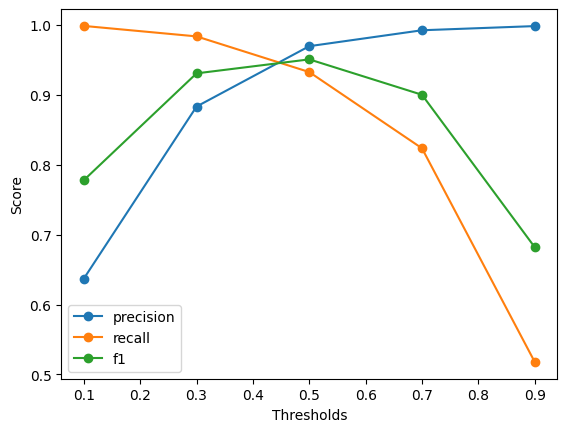

In [207]:
thresholds_df.plot( x = "threshold", y = ["precision", "recall", "f1"], marker = 'o')
plt.xlabel("Thresholds")
plt.ylabel("Score")
plt.show()

#■ 실제 데이터 확인

In [208]:
results = pd.DataFrame({
    "headline" : X_test,
    "actual" : y_test,
    "predict" : y_pred,
    "proba" : y_proba
}).sort_values("proba", ascending=False)

results.head()

,headline,actual,predict,proba
10727,27 Adorable Harry Potter Things Your Baby Needs,1,1,0.998831
15122,We Know Which Thanksgiving Side You Are Based ...,1,1,0.998793
12461,What 2015 Thing Should You Be For Halloween,1,1,0.998768
2635,Here's What You Actually Need To Know About Gr...,1,1,0.998714
9051,We Know What Your Love Life Will Look Like In ...,1,1,0.998596


In [209]:
results_FN = results[
    (results["actual"] == 1) & (results["predict"]==0)
]
results_FN

,headline,actual,predict,proba
10373,Trader Joe's Parking,1,0,0.498490
11361,For Everyone Who Was Weirdly Into Jack Skellin...,1,0,0.497629
1698,Lisa Frank Illustrations Used To Outline The P...,1,0,0.497047
15363,Are You A Bagel Or A Doughnut,1,0,0.494215
12139,"Sam Hunt's ""Break Up In A Small Town"" Video Is...",1,0,0.492784
...,...,...,...,...
2157,"Hark, These Public Libraries Are Dueling To Th...",1,0,0.079593
1650,Why Military Suicide Prevention Fails,1,0,0.078864
1090,What's In Your Air,1,0,0.071442
12622,Are You Taller Than Barack Obama,1,0,0.065514


In [210]:
results_FP = results[
    (results["actual"] == 0) & (results["predict"]==1)
]
results_FP

,headline,actual,predict,proba
18918,Shorten the Backswing to Calm Things Down,0,1,0.927821
25428,"Accounts, People & Miscellany",0,1,0.910696
29276,"Accounts, People, Miscellany",0,1,0.910696
28245,"From Netflix, a Step Toward Any Movie, Anytime",0,1,0.866930
25971,The Williams Secrets? Love Racing and Never Lo...,0,1,0.842570
...,...,...,...,...
18947,Daimler Cedes Its 19.9% Stake to Chrysler,0,1,0.510251
16072,Muslim Brotherhood facing troubled times,0,1,0.506633
16539,Long-Lost Lincoln Letter Is Returned to Archives,0,1,0.502574
28398,"At Chesapeake Energy, Shareholders Who Act Lik...",0,1,0.501047


#■ coef 확인

In [211]:
vectorizer = model.named_steps["tfidf"]

In [212]:
feature_names = vectorizer.get_feature_names_out()

In [213]:
coefficients = model.named_steps["clf"].coef_[0]

In [214]:
importance_df = pd.DataFrame({
    "word" : feature_names,
    "coef" : coefficients
}).sort_values("coef", ascending = False)

importance_df

,word,coef
42884,people,6.838287
1165,actually,6.493127
39602,know,6.297195
47669,things,6.294691
40667,make,5.783356
...,...,...
39460,killed,-4.000729
39504,kills,-4.039691
48480,uk,-4.055048
49499,wins,-4.151383


# ■ 모델 수정(min_df, max_df, ngram_range)

In [215]:
model2 = Pipeline(
    [("tfidf", TfidfVectorizer(
        max_features= 50000,
        ngram_range=(1,2),
        min_df = 3,
        max_df = 0.8,
        stop_words = 'english')),
     ("clf", LogisticRegression(
         max_iter = 1000))]
)

In [216]:
model2.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.8, max_features=50000, min_df=3,
                                 ngram_range=(1, 2), stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [217]:
y_pred2 = model2.predict(X_test)

In [218]:
print(classification_report(y_test, y_pred2))
# 차이 없음

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3127
           1       0.97      0.93      0.95      3273

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



In [219]:
model3 = Pipeline(
    [("tfidf", TfidfVectorizer(
        max_features= 50000,
        ngram_range=(1,3),
        stop_words = 'english')),
     ("clf", LogisticRegression(
         max_iter = 1000))]
)

In [220]:
model3.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 3),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [221]:
y_pred3 = model3.predict(X_test)

In [222]:
print(classification_report(y_test, y_pred3))
# 차이 없음

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3127
           1       0.97      0.93      0.95      3273

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



In [223]:
vectorizer2 = model2.named_steps["tfidf"]
vectorizer3 = model3.named_steps["tfidf"]

In [224]:
feature_names2 = vectorizer2.get_feature_names_out()
feature_names3 = vectorizer3.get_feature_names_out()

In [225]:
coefficients2 = model2.named_steps["clf"].coef_[0]
coefficients3 = model3.named_steps["clf"].coef_[0]

In [226]:
importance_df2 = pd.DataFrame({
    "word" : feature_names2,
    "coef" : coefficients2,
})

importance_df2.sort_values("coef", ascending = False)
# 단어 중요도 기준으로 보면 2버전이 그나마?

,word,coef
601,actually,5.999109
10635,things,5.963680
6023,know,5.866239
7874,people,5.856739
235,2015,5.044110
...,...,...
11097,uk,-3.783140
5956,killed,-3.783441
5977,kills,-3.887792
11664,wins,-3.938843


In [227]:
importance_df3 = pd.DataFrame({
    "word" : feature_names3,
    "coef" : coefficients3
})

importance_df3.sort_values("coef", ascending = False)

,word,coef
42018,people,6.609550
47294,things,6.466842
1415,actually,6.445567
38355,know,6.429967
39573,make,5.654341
...,...,...
38254,kills,-4.079706
48251,uk,-4.084617
38204,killed,-4.090905
49404,wins,-4.126970


# ■ Unigram Model

In [228]:
model4 = Pipeline(
    [("tfidf", TfidfVectorizer(
        max_features= 50000,
        stop_words = 'english')),
     ("clf", LogisticRegression(
         max_iter = 1000))]
)

In [229]:
model4.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [230]:
y_pred4 = model4.predict(X_test)

In [231]:
print(classification_report(y_test, y_pred4))
# Unigram인데 recall이 증가?

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3127
           1       0.97      0.93      0.95      3273

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



In [232]:
confusion_matrix(y_test, y_pred4)
# bigram의 cm
#       array([[3031,   96],
#            [ 221, 3052]])

array([[3049,   78],
       [ 244, 3029]])

In [233]:
y_proba4 = model4.predict_proba(X_test)[:,1]

In [240]:
results4 = pd.DataFrame({
    "headline" : X_test,
    "actual" : y_test,
    "predict" : y_pred4,
    "proba" : y_proba4
}).sort_values("proba", ascending = False)

results4

,headline,actual,predict,proba
2471,21 People Who Really Know What Life Is All About,1,1,0.999937
10933,"We Know Which ""Game Of Thrones"" Character You ...",1,1,0.999816
9051,We Know What Your Love Life Will Look Like In ...,1,1,0.999813
10276,21 Insane Things That Were Actually Said To Pe...,1,1,0.999811
2904,21 Things You'll Just Get If You're Vain AF,1,1,0.999754
...,...,...,...,...
28401,"2007 Rugby World Cup: New Zealand, Australia a...",0,0,0.005456
27252,Former ECB chief Wim Duisenberg dies,0,0,0.004828
27695,"British soldier dies in Afghanistan, UK death ...",0,0,0.004072
23123,Crash in Iraq Kills 4 U.S. Soldiers,0,0,0.003826


In [241]:
results4_FN = results4[
    (results4["actual"]==1) & (results4["predict"]==0)
    ]
results4_FN

,headline,actual,predict,proba
5875,How British Is Your Dad,1,0,0.499637
4253,I Successfully Proposed To My Girlfriend And N...,1,0,0.499208
2333,Which Ryan Murphy Show Are You,1,0,0.498399
10185,For Anyone Who Realizes They Have Turned Into ...,1,0,0.497677
11361,For Everyone Who Was Weirdly Into Jack Skellin...,1,0,0.497088
...,...,...,...,...
1650,Why Military Suicide Prevention Fails,1,0,0.081224
2157,"Hark, These Public Libraries Are Dueling To Th...",1,0,0.076762
1090,What's In Your Air,1,0,0.073234
8358,Which Of The Final Three Houseguests Should Wi...,1,0,0.053804


In [242]:
results4_FP = results4[
    (results4["actual"]==0) & (results4["predict"]==1)
    ]
results4_FP

,headline,actual,predict,proba
28245,"From Netflix, a Step Toward Any Movie, Anytime",0,1,0.854706
25428,"Accounts, People & Miscellany",0,1,0.853596
29276,"Accounts, People, Miscellany",0,1,0.853596
25971,The Williams Secrets? Love Racing and Never Lo...,0,1,0.814061
18124,Just Another Beer? Not to Those in Laos,0,1,0.808995
...,...,...,...,...
27111,New Yorker Cover Art Is Painted With an iPhone,0,1,0.515342
29619,MyBook Disk Drive Handles Lots of Easy Backups,0,1,0.514051
29874,Shriver speaks out over Schwarzenegger’s affai...,0,1,0.509632
16420,BBC broadcasts first live episode of EastEnders,0,1,0.508738


In [243]:
results4.loc[[18947, 16072, 16539, 28398, 26959	]]  #기존 model FP proba 하위 5 > 걸러냄

,headline,actual,predict,proba
18947,Daimler Cedes Its 19.9% Stake to Chrysler,0,0,0.454114
16072,Muslim Brotherhood facing troubled times,0,0,0.448032
16539,Long-Lost Lincoln Letter Is Returned to Archives,0,0,0.499703
28398,"At Chesapeake Energy, Shareholders Who Act Lik...",0,0,0.465498
26959,Trials for Parents Who Chose Faith Over Medicine,0,0,0.492057


In [238]:
vectorizer4 = model4.named_steps["tfidf"]
feature_names4 = vectorizer4.get_feature_names_out()
coefficients4 = model4.named_steps["clf"].coef_[0]

In [239]:
importance_df4 = pd.DataFrame({
    "word" : feature_names4,
    "coef" : coefficients4,
})

importance_df4.sort_values("coef", ascending = False)

,word,coef
10155,know,6.134368
578,actually,5.896663
13369,people,5.879138
18262,things,5.691620
11028,make,5.121567
...,...,...
10064,killed,-3.642309
18933,uk,-3.748495
10072,kills,-3.778931
19943,wins,-3.933746


## Conclusion

- Increasing the n-gram range from unigram to trigram did not meaningfully improve performance.
- Unigram features slightly outperformed larger n-grams in this dataset.